
# DressMe — Data Understanding multi-sources

**Objectif :** explorer les sources de données utilisées pour le projet **DressMe — Personal Fashion Assistant** sans téléchargement manuel par l'utilisateur.

Sources :
1. **Fashion Product Images Dataset** — Kaggle
2. **iMaterialist Fashion 2020 (FGVC7)** — Kaggle Competition
3. **Polyvore Dataset** — GitHub
4. **DigiKlothes** — GitHub
5. **HA Tunisie** — catalogue en ligne

> Le notebook télécharge/clône automatiquement les sources dans l'environnement d'exécution avec `kagglehub`, `git` et `requests`. Il ne demande donc pas de sélectionner un fichier CSV manuellement.

### Ce que l'on cherche pour DressMe

- quantité de données
- types de fichiers
- catégories de vêtements
- couleurs
- saisons / usages
- descriptions
- prix lorsque disponibles
- marques lorsque disponibles
- images et qualité des images
- données d'outfits et compatibilité
- valeurs manquantes / doublons
- intérêt de chaque source pour les futures fonctionnalités de DressMe

### Remarque importante

Les sources n'ont pas la même structure. Le notebook **n'essaie pas de les fusionner directement** : il commence par comprendre chaque source séparément, puis construit à la fin une vue comparative et une proposition de schéma commun.


In [ ]:

# 0. Installation / imports

# Dans Google Colab, décommenter si nécessaire :
# !pip -q install kagglehub requests beautifulsoup4 lxml pillow

import os
import re
import json
import glob
import shutil
import subprocess
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display, Image as IPImage

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Environnement prêt.")


Environnement prêt.


In [ ]:

# 1. Configuration des sources

DATA_ROOT = Path("/content/dressme_data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

KAGGLE_FASHION = "paramaggarwal/fashion-product-images-dataset"
KAGGLE_IMATERIALIST = "imaterialist-fashion-2020-fgvc7"

POLYVORE_URL = "https://github.com/xthan/polyvore-dataset.git"
DIGIKLOTHES_URL = "https://github.com/MsnAmiri/DigiKlothes.git"

HA_URL = "https://ha.com.tn/catalogue/"

print("Répertoire de travail :", DATA_ROOT)


Répertoire de travail : /content/dressme_data


## 2. Source 1 — Fashion Product Images Dataset (Kaggle)

In [ ]:

# Téléchargement automatique via kagglehub
import kagglehub

fashion_path = kagglehub.dataset_download(KAGGLE_FASHION)

print("Path Fashion Product Images :", fashion_path)
print("\nPremiers fichiers :")
for p in list(Path(fashion_path).rglob("*"))[:30]:
    print(p)


Using Colab cache for faster access to the 'fashion-product-images-dataset' dataset.
Path Fashion Product Images : /kaggle/input/fashion-product-images-dataset

Premiers fichiers :
/kaggle/input/fashion-product-images-dataset/fashion-dataset
/kaggle/input/fashion-product-images-dataset/fashion-dataset/images.csv
/kaggle/input/fashion-product-images-dataset/fashion-dataset/images
/kaggle/input/fashion-product-images-dataset/fashion-dataset/styles.csv
/kaggle/input/fashion-product-images-dataset/fashion-dataset/styles
/kaggle/input/fashion-product-images-dataset/fashion-dataset/fashion-dataset
/kaggle/input/fashion-product-images-dataset/fashion-dataset/images/31973.jpg
/kaggle/input/fashion-product-images-dataset/fashion-dataset/images/30778.jpg
/kaggle/input/fashion-product-images-dataset/fashion-dataset/images/19812.jpg
/kaggle/input/fashion-product-images-dataset/fashion-dataset/images/22735.jpg
/kaggle/input/fashion-product-images-dataset/fashion-dataset/images/38246.jpg
/kaggle/inp

In [ ]:

# Recherche automatique des CSV
fashion_csvs = list(Path(fashion_path).rglob("*.csv"))

print("CSV trouvés :", len(fashion_csvs))
for p in fashion_csvs:
    print(" -", p)

# Le dataset classique contient généralement styles.csv
fashion_csv = next((p for p in fashion_csvs if p.name.lower() == "styles.csv"), None)

if fashion_csv is None and fashion_csvs:
    fashion_csv = fashion_csvs[0]

if fashion_csv is not None:
    fashion_df = pd.read_csv(fashion_csv, on_bad_lines="skip")
    print("\nFichier chargé :", fashion_csv)
    print("Shape :", fashion_df.shape)
    display(fashion_df.head())
else:
    fashion_df = pd.DataFrame()
    print("Aucun CSV trouvé.")


CSV trouvés : 4
 - /kaggle/input/fashion-product-images-dataset/fashion-dataset/images.csv
 - /kaggle/input/fashion-product-images-dataset/fashion-dataset/styles.csv
 - /kaggle/input/fashion-product-images-dataset/fashion-dataset/fashion-dataset/images.csv
 - /kaggle/input/fashion-product-images-dataset/fashion-dataset/fashion-dataset/styles.csv

Fichier chargé : /kaggle/input/fashion-product-images-dataset/fashion-dataset/styles.csv
Shape : (44424, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [ ]:

# Data Understanding — structure générale
if not fashion_df.empty:
    print("Dimensions :", fashion_df.shape)
    print("\nTypes :")
    display(fashion_df.dtypes.to_frame("dtype"))

    print("\nInformations :")
    display(fashion_df.info())

    print("\nValeurs manquantes :")
    missing = fashion_df.isna().sum().sort_values(ascending=False)
    display(missing[missing > 0].to_frame("missing_count"))

    print("\nDoublons :", fashion_df.duplicated().sum())

    print("\nStatistiques descriptives :")
    display(fashion_df.describe(include="all").T)


Dimensions : (44424, 10)

Types :


,dtype
id,int64
gender,object
masterCategory,object
subCategory,object
articleType,object
baseColour,object
season,object
year,float64
usage,object
productDisplayName,object



Informations :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  object 
 2   masterCategory      44424 non-null  object 
 3   subCategory         44424 non-null  object 
 4   articleType         44424 non-null  object 
 5   baseColour          44409 non-null  object 
 6   season              44403 non-null  object 
 7   year                44423 non-null  float64
 8   usage               44107 non-null  object 
 9   productDisplayName  44417 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB


None


Valeurs manquantes :


,missing_count
usage,317
season,21
baseColour,15
productDisplayName,7
year,1



Doublons : 0

Statistiques descriptives :


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,44424.0,NaN,NaN,NaN,29696.334301,17049.490518,1163.0,14768.75,28618.5,44683.25,60000.0
gender,44424,5,Men,22147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
masterCategory,44424,7,Apparel,21397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subCategory,44424,45,Topwear,15402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
articleType,44424,143,Tshirts,7067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
baseColour,44409,46,Black,9728,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,44403,4,Summer,21472,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,44423.0,NaN,NaN,NaN,2012.806497,2.12648,2007.0,2011.0,2012.0,2015.0,2019.0
usage,44107,8,Casual,34406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
productDisplayName,44417,31121,Lucera Women Silver Earrings,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

# Colonnes catégorielles principales
if not fashion_df.empty:
    candidate_cols = [
        "gender", "masterCategory", "subCategory", "articleType",
        "baseColour", "season", "year", "usage"
    ]

    for col in candidate_cols:
        if col in fashion_df.columns:
            print(f"\n### {col}")
            print("Nombre de modalités :", fashion_df[col].nunique(dropna=True))
            display(fashion_df[col].value_counts(dropna=False).head(20).to_frame("count"))



### gender
Nombre de modalités : 5


,count
gender,
Men,22147
Women,18631
Unisex,2161
Boys,830
Girls,655



### masterCategory
Nombre de modalités : 7


,count
masterCategory,
Apparel,21397
Accessories,11274
Footwear,9219
Personal Care,2403
Free Items,105
Sporting Goods,25
Home,1



### subCategory
Nombre de modalités : 45


...

,count
season,
Summer,21472
Fall,11431
Winter,8517
Spring,2983
NaN,21



### year
Nombre de modalités : 13


,count
year,
2012.0,16288
2011.0,13672
2016.0,6006
2017.0,2916
2015.0,2780
2013.0,1212
2010.0,846
2018.0,405
2014.0,236



### usage
Nombre de modalités : 8


,count
usage,
Casual,34406
Sports,4025
Ethnic,3208
Formal,2345
NaN,317
Smart Casual,67
Party,29
Travel,26
Home,1


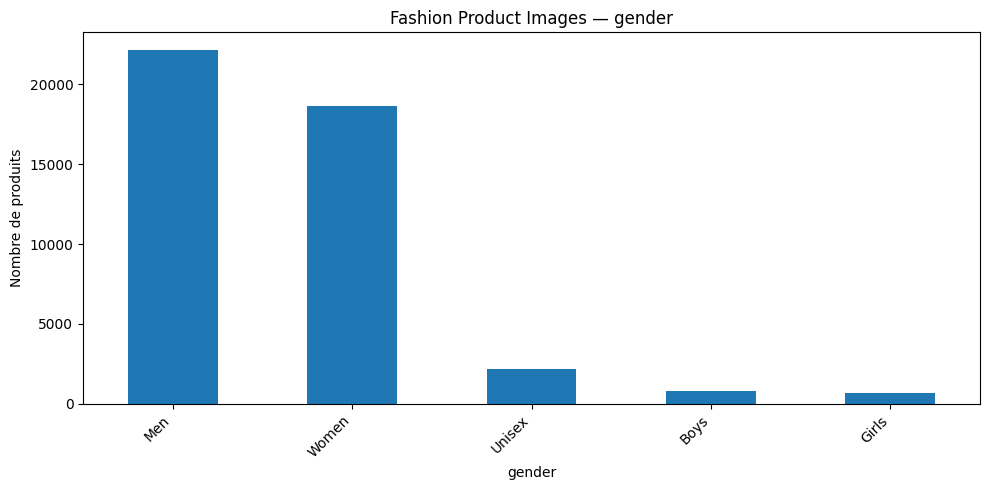

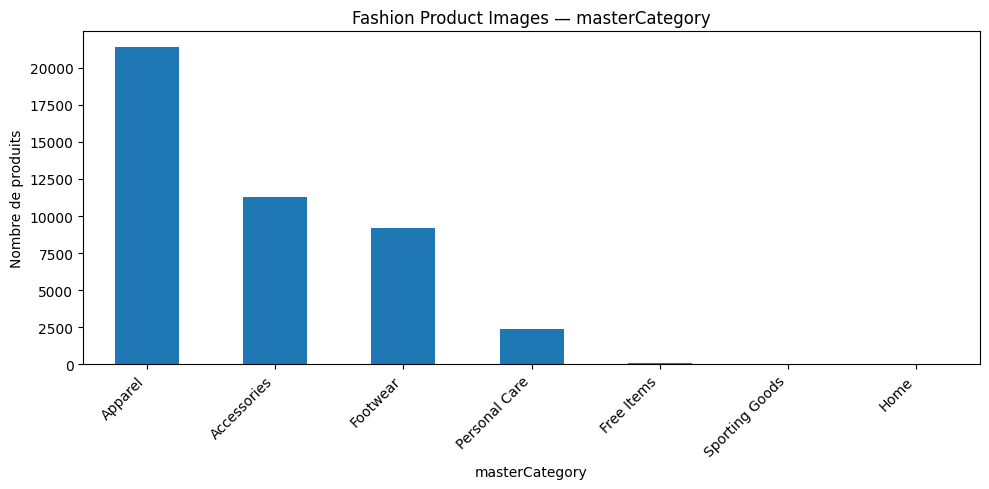

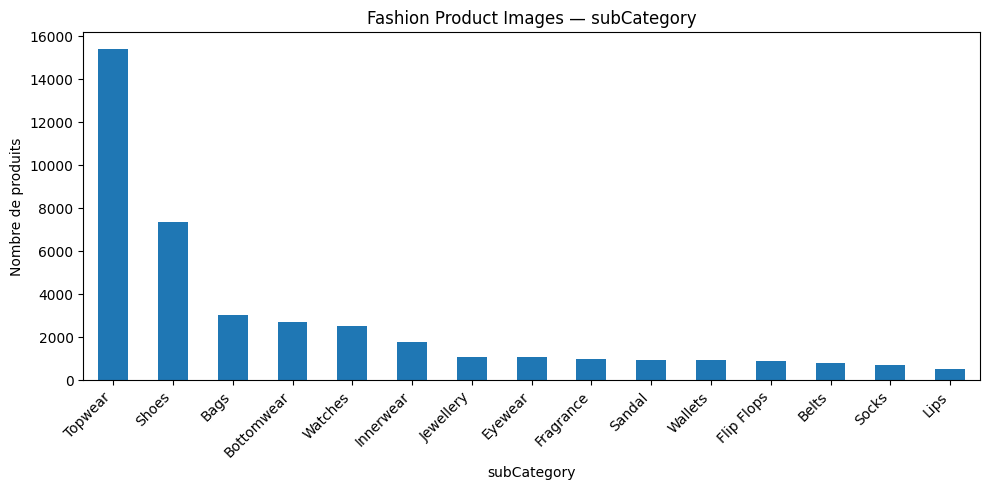

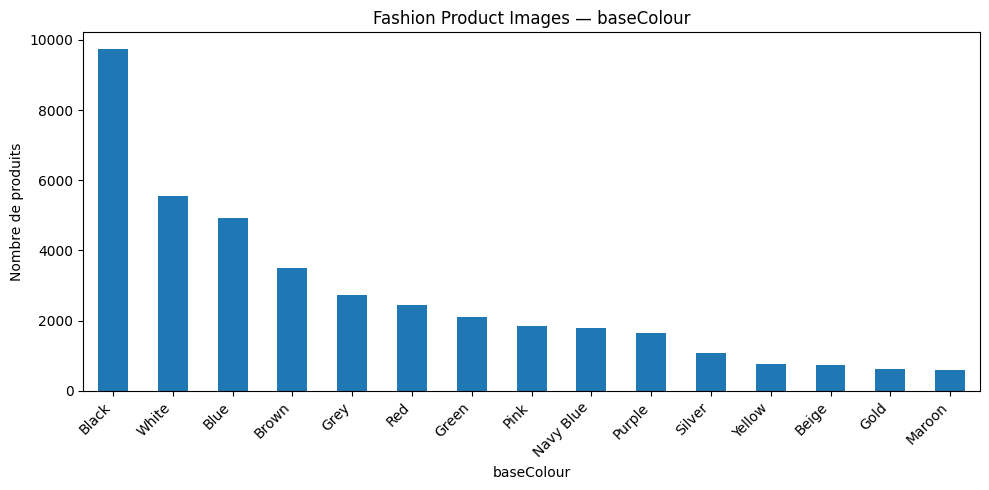

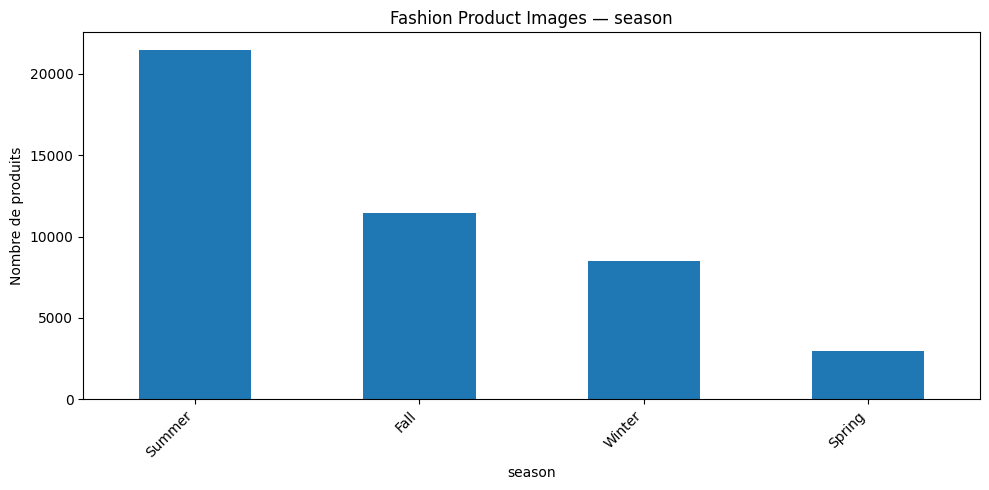

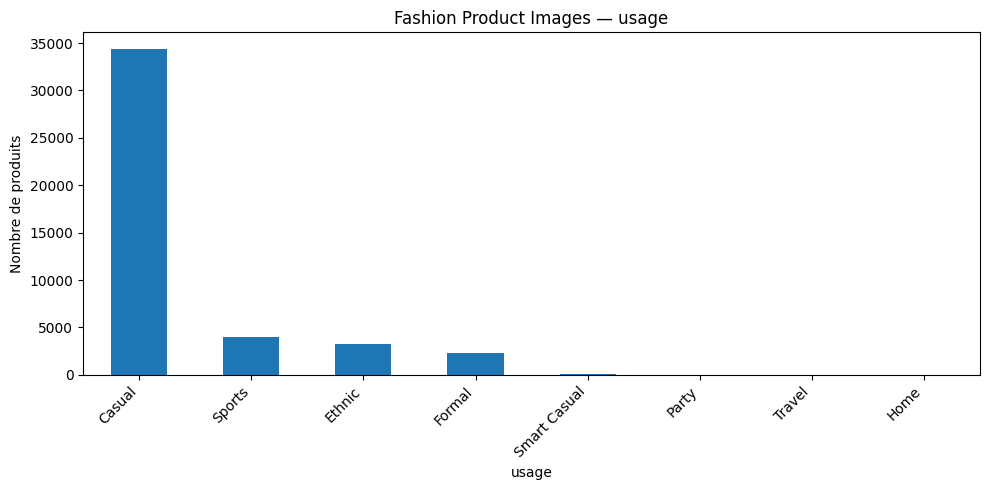

In [ ]:

# Visualisations Fashion Product Images
if not fashion_df.empty:
    for col in ["gender", "masterCategory", "subCategory", "baseColour", "season", "usage"]:
        if col in fashion_df.columns:
            plt.figure(figsize=(10, 5))
            fashion_df[col].value_counts().head(15).plot(kind="bar")
            plt.title(f"Fashion Product Images — {col}")
            plt.ylabel("Nombre de produits")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()


In [ ]:

# Analyse des images
if not fashion_df.empty:
    image_candidates = list(Path(fashion_path).rglob("*.jpg")) + list(Path(fashion_path).rglob("*.jpeg")) + list(Path(fashion_path).rglob("*.png"))
    print("Nombre d'images trouvées :", len(image_candidates))

    dimensions = []
    for img_path in image_candidates[:1000]:  # échantillon pour éviter un traitement trop long
        try:
            with Image.open(img_path) as im:
                dimensions.append((im.width, im.height))
        except Exception:
            pass

    if dimensions:
        dim_df = pd.DataFrame(dimensions, columns=["width", "height"])
        display(dim_df.describe())
        print("Images analysées :", len(dim_df))
        print("Exemples de dimensions :", dim_df.head().to_dict("records"))


Nombre d'images trouvées : 88882


,width,height
count,1000.000000,1000.000000
mean,1406.454000,1875.896000
std,367.863161,494.830992
min,150.000000,200.000000
25%,1080.000000,1440.000000
50%,1080.000000,1440.000000
75%,1800.000000,2400.000000
max,3744.000000,5616.000000


Images analysées : 1000
Exemples de dimensions : [{'width': 1080, 'height': 1440}, {'width': 1800, 'height': 2400}, {'width': 1800, 'height': 2400}, {'width': 1080, 'height': 1440}, {'width': 1800, 'height': 2400}]



### Interprétation attendue pour DressMe

Cette source est particulièrement utile pour comprendre les **produits individuels** et leurs attributs structurés : catégorie, sous-catégorie, type d'article, couleur, saison et usage.

Elle est donc adaptée comme base pour :
- classification de vêtements
- analyse d'attributs
- préparation des métadonnées d'un vêtement
- recherche de similarité
- création d'un catalogue de référence

En revanche, il faut vérifier quelles informations commerciales sont réellement présentes avant de supposer la disponibilité de **prix** ou de **marques**.


## 3. Source 2 — iMaterialist Fashion 2020 (FGVC7)

In [ ]:

# Téléchargement automatique via kagglehub
# ATTENTION : cette compétition peut nécessiter une authentification/acceptation des règles Kaggle.
try:
    imaterialist_path = kagglehub.competition_download(KAGGLE_IMATERIALIST)
    print("Path iMaterialist :", imaterialist_path)
except Exception as e:
    imaterialist_path = None
    print("Le téléchargement iMaterialist a échoué.")
    print("Cause :", repr(e))
    print("Si Kaggle demande une autorisation, connecte ton compte Kaggle dans l'environnement puis relance cette cellule.")


Le téléchargement iMaterialist a échoué.
Cause : UnauthenticatedError('User is not authenticated')
Si Kaggle demande une autorisation, connecte ton compte Kaggle dans l'environnement puis relance cette cellule.


In [ ]:

if imaterialist_path:
    print("Fichiers iMaterialist :")
    for p in list(Path(imaterialist_path).rglob("*"))[:80]:
        print(p)


In [ ]:

# Découverte automatique des CSV / JSON iMaterialist
if imaterialist_path:
    im_csvs = list(Path(imaterialist_path).rglob("*.csv"))
    im_jsons = list(Path(imaterialist_path).rglob("*.json"))

    print("CSV :", len(im_csvs))
    for p in im_csvs:
        print(" -", p)

    print("\nJSON :", len(im_jsons))
    for p in im_jsons:
        print(" -", p)

    # Charger un CSV représentatif sans supposer son nom exact
    imaterialist_df = pd.DataFrame()

    for p in im_csvs:
        try:
            tmp = pd.read_csv(p, nrows=10)
            if len(tmp.columns) > 1:
                print("\nAperçu :", p)
                display(tmp.head())
                imaterialist_df = pd.read_csv(p, on_bad_lines="skip")
                print("Shape :", imaterialist_df.shape)
                break
        except Exception as e:
            print("Impossible de lire", p, ":", e)
else:
    imaterialist_df = pd.DataFrame()


In [ ]:

# Exploration iMaterialist
if not imaterialist_df.empty:
    print("Colonnes :")
    print(imaterialist_df.columns.tolist())

    print("\nTypes :")
    display(imaterialist_df.dtypes.to_frame("dtype"))

    print("\nValeurs manquantes :")
    display(imaterialist_df.isna().sum().sort_values(ascending=False).head(30).to_frame("missing"))

    print("\nDoublons :", imaterialist_df.duplicated().sum())

    print("\nPremières lignes :")
    display(imaterialist_df.head())


In [ ]:

# Images iMaterialist : comptage et échantillon
if imaterialist_path:
    im_images = (
        list(Path(imaterialist_path).rglob("*.jpg")) +
        list(Path(imaterialist_path).rglob("*.jpeg")) +
        list(Path(imaterialist_path).rglob("*.png"))
    )

    print("Images trouvées :", len(im_images))

    if im_images:
        sample_paths = im_images[:12]
        fig = plt.figure(figsize=(14, 8))
        for i, p in enumerate(sample_paths):
            try:
                im = Image.open(p)
                ax = fig.add_subplot(3, 4, i + 1)
                ax.imshow(im)
                ax.set_title(p.name)
                ax.axis("off")
            except Exception:
                pass
        plt.tight_layout()
        plt.show()



### Interprétation attendue pour DressMe

iMaterialist est surtout intéressant pour la **vision par ordinateur** et la segmentation/annotation fine des vêtements. Il peut servir à apprendre à localiser ou reconnaître différentes parties et catégories d'un vêtement.

Cette source est donc davantage orientée **computer vision** que catalogue commercial : elle ne doit pas être considérée comme la source principale des prix, marques tunisiennes ou informations commerciales.


## 4. Source 3 — Polyvore Dataset (GitHub)

In [ ]:

# Clonage automatique du dépôt
polyvore_dir = DATA_ROOT / "polyvore-dataset"

if not polyvore_dir.exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", POLYVORE_URL, str(polyvore_dir)],
        check=True
    )
else:
    print("Dépôt Polyvore déjà présent.")

print("Contenu :")
for p in list(polyvore_dir.iterdir()):
    print(" -", p.name)


Contenu :
 - LICENSE
 - README.md
 - category_id.txt
 - .git
 - polyvore.tar.gz


In [ ]:

# Extraction du fichier polyvore.tar.gz
polyvore_tar = polyvore_dir / "polyvore.tar.gz"
polyvore_extract = polyvore_dir / "extracted"

if polyvore_tar.exists():
    import tarfile
    polyvore_extract.mkdir(exist_ok=True)

    # Extraction uniquement si le dossier semble vide
    if not any(polyvore_extract.iterdir()):
        with tarfile.open(polyvore_tar, "r:gz") as tar:
            tar.extractall(polyvore_extract)
        print("Archive extraite.")
    else:
        print("Archive déjà extraite.")

print("Fichiers JSON trouvés :")
poly_jsons = list(polyvore_extract.rglob("*.json"))
for p in poly_jsons:
    print(" -", p)


/tmp/ipykernel_1822/1189761055.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(polyvore_extract)


Archive extraite.
Fichiers JSON trouvés :
 - /content/dressme_data/polyvore-dataset/extracted/valid_no_dup.json
 - /content/dressme_data/polyvore-dataset/extracted/test_no_dup.json
 - /content/dressme_data/polyvore-dataset/extracted/train_no_dup.json
 - /content/dressme_data/polyvore-dataset/extracted/fill_in_blank_test.json


In [ ]:

# Chargement des splits Polyvore
polyvore_dfs = {}

for split in ["train", "valid", "test"]:
    candidates = list(polyvore_extract.rglob(f"{split}_no_dup.json"))
    if candidates:
        with open(candidates[0], "r", encoding="utf-8") as f:
            data = json.load(f)
        polyvore_dfs[split] = pd.DataFrame(data)
        print(f"{split}: {len(data)} outfits")

polyvore_all = pd.concat(
    [df.assign(split=split) for split, df in polyvore_dfs.items()],
    ignore_index=True
) if polyvore_dfs else pd.DataFrame()

if not polyvore_all.empty:
    display(polyvore_all.head())
    print("Shape :", polyvore_all.shape)


train: 17316 outfits
valid: 1497 outfits
test: 3076 outfits


,name,views,items,image,likes,date,set_url,set_id,desc,split
0,Casual,8743,"[{'index': 1, 'name': 'mock neck embroidery suede sweatshirt', 'price': 24.0, 'likes': 10, 'image': 'http://img2.pol...",http://ak1.polyvoreimg.com/cgi/img-set/cid/214181831/id/El8a99fQ5hG4HrPFO4xqOQ/size/y.jpg,394,One month,http://www.polyvore.com/casual/set?id=214181831,214181831,"A fashion look from January 2017 by beebeely-look featuring Fuji, Citizens of Humanity, casual, casualoutfit, Packan...",train
1,Being a Vans shoe model with Luke. Idk about this title,188,"[{'index': 1, 'name': 'nirvana distressed t-shirt', 'price': 10.0, 'likes': 1290, 'image': 'http://img2.polyvoreimg....",http://ak1.polyvoreimg.com/cgi/img-set/cid/120161271/id/cK1ziNXL4xGfCi6UNxsv_g/size/y.jpg,9,Two years,http://www.polyvore.com/being_vans_shoe_model_with/set?id=120161271,120161271,"A fashion look from April 2014 featuring destroyed shirt, skinny fit jeans and vans shoes. Browse and shop related l...",train
2,These Chanel bags is a bad habit .x,562,"[{'index': 1, 'name': 'monki singlet', 'price': 16.0, 'likes': 20094, 'image': 'http://img2.polyvoreimg.com/cgi/img-...",http://ak1.polyvoreimg.com/cgi/img-set/cid/143656996/id/kOrq5uWH5BGnjr4XnCklpg/size/y.jpg,32,Two years,http://www.polyvore.com/these_chanel_bags_is_bad/set?id=143656996,143656996,12.19.14,train
3,Avenger/Supernatural prp,2613,"[{'index': 1, 'name': 'tops', 'price': 18.0, 'likes': 2036, 'image': 'http://img1.polyvoreimg.com/cgi/img-thing?.out...",http://ak2.polyvoreimg.com/cgi/img-set/cid/186627934/id/BAQVz-Kx5RGoxPTPO4xqOQ/size/y.jpg,88,One year,http://www.polyvore.com/avenger_supernatural_prp/set?id=186627934,186627934,"A fashion look from January 2016 by alyssaclair-winchester featuring Forever 21, Yves Saint Laurent, Allurez and Pla...",train
4,Boho (39),62,"[{'index': 1, 'name': 'yoins leather sexy v-neck sleeveless crop top', 'price': 16.0, 'likes': 6637, 'image': 'http:...",http://ak2.polyvoreimg.com/cgi/img-set/cid/206969379/id/rm0vjp1u5hGYxuJ7O4xqOQ/size/y.jpg,3,5 months,http://www.polyvore.com/boho_39/set?id=206969379,206969379,"A fashion look from August 2016 by kate-goida featuring Alice + Olivia, Etro, Casetify, Lime Crime and Oscar de la R...",train


Shape : (21889, 10)


Colonnes : ['name', 'views', 'items', 'image', 'likes', 'date', 'set_url', 'set_id', 'desc', 'split']

name


,count
name,
Street Style,152
Casual,132
street style,131
Celebrate Our 10th Polyversary!,95
dress,67
School,66
Work Wear,61
Make a Statement: Embellished Sleeves,57
Boho,51



views


,views
count,21889.000000
mean,3849.273608
std,19699.915174
min,4.000000
25%,189.000000
50%,715.000000
75%,2267.000000
max,521627.000000



likes


...

,count
set_id,
148787971,1
208151866,1
142575200,1
106043455,1
114369777,1
148291638,1
212932809,1
216792359,1
124323036,1



desc


,count
desc,
#edgyvalentine,19
A menswear look from January 2017 by jecakns featuring men's fashion and menswear,17
The best celebrity street style of 2013.\n\n#bestof2013\n#streetstyle\n#contest,16
A menswear look from February 2017 by jecakns featuring men's fashion and menswear,13
@polyvore @polyvore-editorial,12
My favorite celebrity makeup look.\n\n#celebritymakeup\n#beauty\n#contest,11
#celebhomedecorstyle,11
An art collage from February 2017 by confusgrk featuring art,11
#60secondstyle\n#edgyvalentine,9



Nombre d'articles par outfit :


,items_per_outfit
count,21889.000000
mean,6.509206
std,1.401401
min,4.000000
25%,5.000000
50%,7.000000
75%,8.000000
max,8.000000


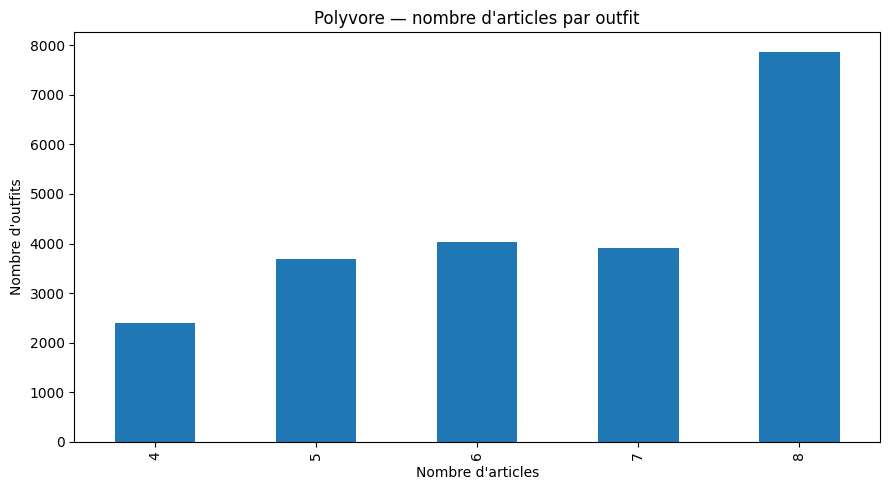

In [ ]:

# Analyse des outfits Polyvore
if not polyvore_all.empty:
    print("Colonnes :", polyvore_all.columns.tolist())

    for col in ["name", "views", "likes", "date", "set_id", "desc"]:
        if col in polyvore_all.columns:
            print(f"\n{col}")
            if pd.api.types.is_numeric_dtype(polyvore_all[col]):
                display(polyvore_all[col].describe().to_frame())
            else:
                display(polyvore_all[col].value_counts(dropna=False).head(10).to_frame("count"))

    # Nombre d'items par outfit
    if "items" in polyvore_all.columns:
        item_counts = polyvore_all["items"].apply(lambda x: len(x) if isinstance(x, list) else np.nan)
        print("\nNombre d'articles par outfit :")
        display(item_counts.describe().to_frame("items_per_outfit"))

        plt.figure(figsize=(9, 5))
        item_counts.value_counts().sort_index().plot(kind="bar")
        plt.title("Polyvore — nombre d'articles par outfit")
        plt.xlabel("Nombre d'articles")
        plt.ylabel("Nombre d'outfits")
        plt.tight_layout()
        plt.show()


In [ ]:

# Transformation des items Polyvore en table exploitable
if not polyvore_all.empty and "items" in polyvore_all.columns:
    rows = []

    for _, outfit in polyvore_all.iterrows():
        items = outfit["items"]
        if isinstance(items, list):
            for item in items:
                if isinstance(item, dict):
                    row = item.copy()
                    row["set_id"] = outfit.get("set_id")
                    row["outfit_name"] = outfit.get("name")
                    row["outfit_date"] = outfit.get("date")
                    rows.append(row)

    polyvore_items = pd.DataFrame(rows)

    print("Nombre d'items :", len(polyvore_items))
    display(polyvore_items.head())

    for col in ["categoryid", "price", "likes"]:
        if col in polyvore_items.columns:
            print(f"\nAnalyse de {col}")
            display(polyvore_items[col].describe(include="all").to_frame())


Nombre d'items : 142480


,index,name,price,likes,image,categoryid,set_id,outfit_name,outfit_date
0,1,mock neck embroidery suede sweatshirt,24.0,10,http://img2.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=194508109,4495,214181831,Casual,One month
1,2,luxe double zip hooded jacket,150.0,2250,http://img2.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=188778349,25,214181831,Casual,One month
2,3,citizens humanity high rise rocket hem jean,248.0,2437,http://img1.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=188977857,27,214181831,Casual,One month
3,4,suede tie short boots,37.0,2,http://img1.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=194942557,261,214181831,Casual,One month
4,5,cloth travel school backpack,22.0,2,http://img2.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=194941874,259,214181831,Casual,One month



Analyse de categoryid


,categoryid
count,142480.000000
mean,330.153937
std,927.299194
min,2.000000
25%,36.000000
50%,61.000000
75%,200.000000
max,4526.000000



Analyse de price


,price
count,142480.000000
mean,532.867089
std,7933.428036
min,-1.000000
25%,19.000000
50%,49.000000
75%,250.000000
max,805483.000000



Analyse de likes


,likes
count,142480.000000
mean,2728.790279
std,4912.076142
min,1.000000
25%,81.000000
50%,684.000000
75%,3192.000000
max,89214.000000



### Interprétation pour DressMe

Polyvore apporte une information différente : **les relations entre vêtements dans un même outfit**.

C'est particulièrement intéressant pour :
- recommandation d'outfits
- apprentissage de la compatibilité entre articles
- prédiction de l'article qui complète une tenue
- modèles de similarité/compatibilité

Le dépôt indique notamment 21 889 outfits répartis entre train/validation/test et une table `category_id.txt` permettant de relier les identifiants de catégories aux noms. citeturn0search1

Les URLs originales des images ne sont plus toutes disponibles, ce qui doit être pris en compte dans la phase de préparation. citeturn0search1


## 5. Source 4 — DigiKlothes (GitHub)

In [ ]:

# Clonage automatique du dépôt DigiKlothes
digik_dir = DATA_ROOT / "DigiKlothes"

if not digik_dir.exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", DIGIKLOTHES_URL, str(digik_dir)],
        check=True
    )
else:
    print("Dépôt DigiKlothes déjà présent.")

print("Contenu du dépôt :")
for p in list(digik_dir.iterdir()):
    print(" -", p.name)


Contenu du dépôt :
 - LICENSE
 - clean_reduced_Data
 - clean_Data
 - README.md
 - preprocess_reduce.ipynb
 - .git
 - category product scraper.py
 - raw_Data
 - Single product image scraper.py
 - preprocess_clean.ipynb


In [ ]:

# Découverte des CSV DigiKlothes
digik_csvs = list(digik_dir.rglob("*.csv"))

print("CSV trouvés :", len(digik_csvs))
for p in digik_csvs:
    print(" -", p)

digik_tables = {}

for p in digik_csvs:
    try:
        df_tmp = pd.read_csv(p, on_bad_lines="skip")
        digik_tables[str(p.relative_to(digik_dir))] = df_tmp
        print(f"\n{p.name} -> {df_tmp.shape}")
        display(df_tmp.head(3))
    except Exception as e:
        print("Erreur lecture", p, ":", e)


CSV trouvés : 90
 - /content/dressme_data/DigiKlothes/clean_reduced_Data/category-women-jeans.csv
 - /content/dressme_data/DigiKlothes/clean_reduced_Data/category-women-underwear.csv
 - /content/dressme_data/DigiKlothes/clean_reduced_Data/category-men-shirts.csv
 - /content/dressme_data/DigiKlothes/clean_reduced_Data/category-women-legging.csv
 - /content/dressme_data/DigiKlothes/clean_reduced_Data/category-men-jeans.csv
 - /content/dressme_data/DigiKlothes/clean_reduced_Data/category-women-sweatshirts.csv
 - /content/dressme_data/DigiKlothes/clean_reduced_Data/category-men-underwear.csv
 - /content/dressme_data/DigiKlothes/clean_reduced_Data/category-girls-clothing.csv
 - /content/dressme_data/DigiKlothes/clean_reduced_Data/category-women-tops-and-croptops.csv
 - /content/dressme_data/DigiKlothes/clean_reduced_Data/category-men-outwear.csv
 - /content/dressme_data/DigiKlothes/clean_reduced_Data/category-boys-clothing.csv
 - /content/dressme_data/DigiKlothes/clean_reduced_Data/category

,Unnamed: 0,name,link,images
0,0,شلوار جین زنانه مدل مام استایل کد R-H,https://www.digikala.com/product/dkp-5014351/%D8%B4%D9%84%D9%88%D8%A7%D8%B1-%D8%AC%DB%8C%D9%86-%D8%B2%D9%86%D8%A7%D9...,['https://dkstatics-public.digikala.com/digikala-products/e928cd8d0f3072b59a031ff1b8666027c3cd8a02_1619456724.jpg?x-...
1,1,شلوار جین زنانه ال سی وایکیکی مدل 0SC788Z8-507-MIDRODEO,https://www.digikala.com/product/dkp-9146263/%D8%B4%D9%84%D9%88%D8%A7%D8%B1-%D8%AC%DB%8C%D9%86-%D8%B2%D9%86%D8%A7%D9...,['https://dkstatics-public.digikala.com/digikala-products/b6316512254122d308571884a355ce446d72a2e2_1660367517.jpg?x-...
2,2,شلوار جین زنانه مدل نیم بگ V242,https://www.digikala.com/product/dkp-8922297/%D8%B4%D9%84%D9%88%D8%A7%D8%B1-%D8%AC%DB%8C%D9%86-%D8%B2%D9%86%D8%A7%D9...,['https://dkstatics-public.digikala.com/digikala-products/3c67b99e26ddfadc66de7aa7f056fa85a906ca40_1656961121.jpg?x-...



category-women-underwear.csv -> (1980, 4)


,Unnamed: 0,name,link,images
0,0,شورت زنانه اسپست مدل ASP-BYR000 بسته سه عددی,https://www.digikala.com/product/dkp-8946090/%D8%B4%D9%88%D8%B1%D8%AA-%D8%B2%D9%86%D8%A7%D9%86%D9%87-%D8%A7%D8%B3%D9...,['https://dkstatics-public.digikala.com/digikala-products/ef43bd6c12bdc8edaf5d21b6663c253dac0912f3_1657268784.jpg?x-...
1,1,سوتین زنانه کد 9997-F رنگ فیروزه ای,https://www.digikala.com/product/dkp-1844078/%D8%B3%D9%88%D8%AA%DB%8C%D9%86-%D8%B2%D9%86%D8%A7%D9%86%D9%87-%DA%A9%D8...,"['https://dkstatics-public.digikala.com/digikala-products/117508732.jpg?x-oss-process=image/resize,h_1600/quality,q_..."
2,2,ست شورت و سوتین زنانه کارنا رز مدل فنردار کد 3378-15 رنگ کرم,https://www.digikala.com/product/dkp-8670459/%D8%B3%D8%AA-%D8%B4%D9%88%D8%B1%D8%AA-%D9%88-%D8%B3%D9%88%D8%AA%DB%8C%D...,['https://dkstatics-public.digikala.com/digikala-products/2fb6f600e197e566d028066ea3614229719bee4d_1654356654.jpg?x-...



category-men-shirts.csv -> (2000, 4)


...

,name,price,discount,star,link
0,پیراهن زنانه مدل Eyeful 2021,"۳,۹۹۵,۰۰۰",-,۴.۷,https://www.digikala.com/product/dkp-3274155/%D9%BE%DB%8C%D8%B1%D8%A7%D9%87%D9%86-%D8%B2%D9%86%D8%A7%D9%86%D9%87-%D9...
1,پیراهن ساحلی زنانه بنیس مدل آنلی,"۲۵۸,۰۰۰",-,۳.۹,https://www.digikala.com/product/dkp-8538343/%D9%BE%DB%8C%D8%B1%D8%A7%D9%87%D9%86-%D8%B3%D8%A7%D8%AD%D9%84%DB%8C-%D8...
2,پیراهن زنانه ال سی وایکیکی مدل آستین بلند BO10357,"۱,۰۱۶,۴۰۰",۳۰٪,-,https://www.digikala.com/product/dkp-7597666/%D9%BE%DB%8C%D8%B1%D8%A7%D9%87%D9%86-%D8%B2%D9%86%D8%A7%D9%86%D9%87-%D8...



category-women-skirts.csv -> (1980, 5)


,name,price,discount,star,link
0,دامن زنانه مدل روبینا,"۳۱۵,۰۰۰",-,۳.۸,https://www.digikala.com/product/dkp-4680873/%D8%AF%D8%A7%D9%85%D9%86-%D8%B2%D9%86%D8%A7%D9%86%D9%87-%D9%85%D8%AF%D9...
1,دامن زنانه اسمارا مدل 320829,"۹۹,۰۰۰",-,۳.۸,https://www.digikala.com/product/dkp-4997297/%D8%AF%D8%A7%D9%85%D9%86-%D8%B2%D9%86%D8%A7%D9%86%D9%87-%D8%A7%D8%B3%D9...
2,دامن زنانه اسمارا مدل LS141,"۱۳۹,۰۰۰",-,۴,https://www.digikala.com/product/dkp-7787696/%D8%AF%D8%A7%D9%85%D9%86-%D8%B2%D9%86%D8%A7%D9%86%D9%87-%D8%A7%D8%B3%D9...



category-men-homewear.csv -> (2000, 5)


,name,price,discount,star,link
0,شلوار مردانه مدل کردی کلیه بند,"۱۵۵,۰۰۰",۱۱٪,۳.۶,https://www.digikala.com/product/dkp-6956230/%D8%B4%D9%84%D9%88%D8%A7%D8%B1-%D9%85%D8%B1%D8%AF%D8%A7%D9%86%D9%87-%D9...
1,شلوار راحتی مردانه فرد مدل Sha.r.002,"۱۵۹,۰۰۰",۵۸٪,۳.۷,https://www.digikala.com/product/dkp-2195277/%D8%B4%D9%84%D9%88%D8%A7%D8%B1-%D8%B1%D8%A7%D8%AD%D8%AA%DB%8C-%D9%85%D8...
2,ست تاپ و شلوارک مردانه مدل yk,"۱۸۵,۰۰۰",-,۴,https://www.digikala.com/product/dkp-8010238/%D8%B3%D8%AA-%D8%AA%D8%A7%D9%BE-%D9%88-%D8%B4%D9%84%D9%88%D8%A7%D8%B1%D...


In [ ]:

# Sélection de la table DigiKlothes la plus riche
if digik_tables:
    digik_name, digik_df = max(digik_tables.items(), key=lambda x: x[1].shape[1])
    print("Table sélectionnée :", digik_name)
    print("Shape :", digik_df.shape)

    print("\nColonnes :")
    print(digik_df.columns.tolist())

    print("\nValeurs manquantes :")
    display(digik_df.isna().sum().sort_values(ascending=False).to_frame("missing"))

    print("\nDoublons :", digik_df.duplicated().sum())
else:
    digik_df = pd.DataFrame()


Table sélectionnée : clean_Data/category-women-jeans.csv
Shape : (2000, 7)

Colonnes :
['Unnamed: 0', 'name', 'price', 'discount', 'star', 'link', 'images']

Valeurs manquantes :


,missing
images,12
name,0
Unnamed: 0,0
price,0
discount,0
star,0
link,0



Doublons : 0


In [ ]:

# Analyse des informations commerciales DigiKlothes
if not digik_df.empty:
    for col in digik_df.columns:
        name = col.lower()

        if any(k in name for k in ["price", "discount", "rating"]):
            print(f"\n### {col}")
            numeric = pd.to_numeric(
                digik_df[col].astype(str).str.replace(",", "", regex=False),
                errors="coerce"
            )
            display(numeric.describe().to_frame("statistics"))

    # Longueur des noms
    name_col = next((c for c in digik_df.columns if "name" in c.lower()), None)

    if name_col:
        lengths = digik_df[name_col].fillna("").astype(str).str.len()
        print("\nLongueur des noms :")
        display(lengths.describe().to_frame())



### price


,statistics
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN



### discount


,statistics
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN



Longueur des noms :


,Unnamed: 0
count,2000.000000
mean,3.445000
std,0.605936
min,1.000000
25%,3.000000
50%,3.500000
75%,4.000000
max,4.000000



### Interprétation pour DressMe

DigiKlothes est particulièrement utile pour le volet **catalogue et information commerciale**. Le dépôt décrit plus de 55 000 articles provenant de Digikala et indique la présence du nom, prix, remise, note, URL et URLs des images. citeturn0search2

Il peut donc compléter les sources orientées vision/compatibilité avec des données de **produits et prix**.


## 6. Source 5 — Catalogue HA Tunisie

In [ ]:

# Exploration du catalogue HA directement depuis l'URL
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120 Safari/537.36"
}

try:
    response = requests.get(HA_URL, headers=headers, timeout=30)
    print("Status HTTP :", response.status_code)
    print("Taille HTML :", len(response.text))
except Exception as e:
    response = None
    print("Erreur :", repr(e))


Status HTTP : 200
Taille HTML : 6833


In [ ]:

# Extraction prudente des liens et textes du catalogue
ha_df = pd.DataFrame()

if response is not None and response.ok:
    soup = BeautifulSoup(response.text, "lxml")

    links = []
    for a in soup.find_all("a", href=True):
        href = urljoin(HA_URL, a["href"])
        text = " ".join(a.get_text(" ", strip=True).split())

        if text or href:
            links.append({"text": text, "url": href})

    ha_links = pd.DataFrame(links).drop_duplicates()

    print("Nombre de liens détectés :", len(ha_links))
    display(ha_links.head(30))

    # Détection de blocs contenant des prix
    price_pattern = re.compile(r"(?:TND|DT|د\.ت|د\.ت\.|€|EUR|\$)", re.I)

    records = []
    for tag in soup.find_all(["article", "li", "div"]):
        txt = " ".join(tag.get_text(" ", strip=True).split())

        if txt and price_pattern.search(txt):
            img = tag.find("img")
            a = tag.find("a", href=True)

            records.append({
                "text": txt[:500],
                "image_url": urljoin(HA_URL, img.get("src")) if img and img.get("src") else None,
                "product_url": urljoin(HA_URL, a["href"]) if a else None
            })

    ha_df = pd.DataFrame(records).drop_duplicates()

    print("\nBlocs contenant potentiellement un prix :", len(ha_df))
    display(ha_df.head(20))
else:
    print("Le catalogue n'a pas pu être récupéré automatiquement.")


Nombre de liens détectés : 0


""



Blocs contenant potentiellement un prix : 0


""


In [ ]:

# Analyse simple du catalogue HA
if not ha_df.empty:
    print("Shape :", ha_df.shape)
    print("\nValeurs manquantes :")
    display(ha_df.isna().sum().to_frame("missing"))

    print("\nExemples de textes produits :")
    display(ha_df["text"].head(20).to_frame())

    print("\nImages détectées :", ha_df["image_url"].notna().sum())
    print("URLs produits détectées :", ha_df["product_url"].notna().sum())

    # Aperçu des produits avec image
    sample = ha_df.dropna(subset=["image_url"]).head(12)

    if not sample.empty:
        fig = plt.figure(figsize=(14, 8))
        for i, (_, row) in enumerate(sample.iterrows()):
            try:
                img_resp = requests.get(row["image_url"], headers=headers, timeout=10)
                if img_resp.ok:
                    from io import BytesIO
                    im = Image.open(BytesIO(img_resp.content)).convert("RGB")
                    ax = fig.add_subplot(3, 4, i + 1)
                    ax.imshow(im)
                    ax.set_title(row["text"][:45], fontsize=8)
                    ax.axis("off")
            except Exception:
                pass

        plt.tight_layout()
        plt.show()



### Interprétation pour DressMe

HA est utilisé ici comme **source tunisienne réelle** pour compléter les datasets génériques avec un contexte local : produits, catégories, prix et images lorsqu'ils sont accessibles.

La structure HTML d'un site commercial peut changer. Le scraping doit donc être considéré comme une étape d'acquisition à maintenir, et les conditions d'utilisation/droits sur les données et images doivent être vérifiés avant toute redistribution.


## 7. Comparaison des sources pour DressMe

In [ ]:

comparison = pd.DataFrame({
    "Source": [
        "Fashion Product Images",
        "iMaterialist Fashion 2020",
        "Polyvore",
        "DigiKlothes",
        "HA Tunisie"
    ],
    "Images": [
        "Oui",
        "Oui",
        "Oui / URLs historiques",
        "Oui / URLs",
        "Oui / selon disponibilité"
    ],
    "Catégories": [
        "Oui",
        "Oui / annotations",
        "Oui",
        "À vérifier selon table",
        "À extraire"
    ],
    "Couleurs": [
        "Oui",
        "Annotations visuelles",
        "Pas comme attribut principal",
        "Pas garanti",
        "À extraire"
    ],
    "Prix": [
        "Pas l'attribut principal",
        "Non",
        "Oui, généralement USD",
        "Oui",
        "Oui, si présent dans le catalogue"
    ],
    "Marques": [
        "Pas garanti",
        "Non",
        "Pas fiable comme marque",
        "Pas l'attribut principal",
        "À extraire"
    ],
    "Outfits": [
        "Non",
        "Non",
        "Oui",
        "Non",
        "Non"
    ],
    "Compatibilité": [
        "Indirecte",
        "Vision",
        "Oui",
        "Indirecte",
        "Non"
    ],
    "Contexte tunisien": [
        "Non",
        "Non",
        "Non",
        "Non",
        "Oui"
    ]
})

display(comparison)


,Source,Images,Catégories,Couleurs,Prix,Marques,Outfits,Compatibilité,Contexte tunisien
0,Fashion Product Images,Oui,Oui,Oui,Pas l'attribut principal,Pas garanti,Non,Indirecte,Non
1,iMaterialist Fashion 2020,Oui,Oui / annotations,Annotations visuelles,Non,Non,Non,Vision,Non
2,Polyvore,Oui / URLs historiques,Oui,Pas comme attribut principal,"Oui, généralement USD",Pas fiable comme marque,Oui,Oui,Non
3,DigiKlothes,Oui / URLs,À vérifier selon table,Pas garanti,Oui,Pas l'attribut principal,Non,Indirecte,Non
4,HA Tunisie,Oui / selon disponibilité,À extraire,À extraire,"Oui, si présent dans le catalogue",À extraire,Non,Non,Oui



## 8. Proposition de schéma commun DressMe

Après le Data Understanding, on peut préparer une table normalisée avec des champs comme :

| Champ DressMe | Rôle |
|---|---|
| `item_id` | identifiant interne |
| `source` | source d'origine |
| `image_url` / `image_path` | image du vêtement |
| `name` | nom du produit |
| `description` | description |
| `category` | catégorie principale |
| `subcategory` | sous-catégorie |
| `article_type` | type précis |
| `color` | couleur |
| `season` | saison |
| `usage` | usage |
| `style` | style |
| `material` | matière |
| `brand` | marque |
| `price` | prix |
| `currency` | devise |
| `discount` | remise |
| `rating` | note |
| `outfit_id` | identifiant d'une tenue |
| `compatibility_label` | compatibilité |
| `country_context` | contexte/localisation |

**Important :** les champs qui n'existent pas dans une source doivent rester `NaN`/vides. Il ne faut pas inventer une information absente.

### Pourquoi cette normalisation ?

Elle permettra ensuite de combiner :
- **vision / attributs** → Fashion Product Images + iMaterialist
- **compatibilité / outfits** → Polyvore
- **prix / catalogue** → DigiKlothes
- **contexte tunisien** → HA Tunisie

Cela prépare les étapes suivantes : preprocessing, extraction de features/embeddings, recherche de similarité et système de recommandation.


In [ ]:

# 9. Résumé automatique — fichiers et volumes réellement récupérés

summary_rows = []

def add_summary(name, df=None, root=None):
    row = {"source": name}

    if df is not None and not df.empty:
        row["rows"] = len(df)
        row["columns"] = len(df.columns)
    else:
        row["rows"] = None
        row["columns"] = None

    if root is not None and Path(root).exists():
        row["files"] = sum(1 for p in Path(root).rglob("*") if p.is_file())
        row["images"] = sum(
            1 for p in Path(root).rglob("*")
            if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
        )
    else:
        row["files"] = None
        row["images"] = None

    summary_rows.append(row)

add_summary("Fashion Product Images", fashion_df, fashion_path)
add_summary("iMaterialist", imaterialist_df, imaterialist_path)
add_summary("Polyvore", polyvore_all, polyvore_dir)
add_summary("DigiKlothes", digik_df, digik_dir)
add_summary("HA Tunisie", ha_df, None)

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,source,rows,columns,files,images
0,Fashion Product Images,44424.0,10.0,177778.0,88882.0
1,iMaterialist,NaN,NaN,NaN,NaN
2,Polyvore,21889.0,10.0,38.0,0.0
3,DigiKlothes,2000.0,7.0,125.0,0.0
4,HA Tunisie,NaN,NaN,NaN,NaN



# 10. Conclusion du Data Understanding

### Ce que DressMe peut retenir

**1. Fashion Product Images**
- source structurée pour les attributs des produits
- utile pour la classification et l'analyse des vêtements

**2. iMaterialist**
- source orientée vision et annotations
- utile pour les modèles de computer vision / segmentation

**3. Polyvore**
- source clé pour comprendre les **relations entre vêtements**
- utile pour la recommandation d'outfits et la compatibilité

**4. DigiKlothes**
- source orientée catalogue commercial
- utile pour les noms, prix, remises, notes et images

**5. HA Tunisie**
- source locale permettant d'introduire un contexte tunisien
- utile pour les produits/prix/images accessibles du catalogue

### Étape suivante recommandée

Après ce notebook :

`Data Understanding → Data Cleaning → Data Integration → Feature Engineering → Embeddings/Computer Vision → Similarity → Recommendation → Virtual Try-On`

Le point important est de **ne pas fusionner immédiatement les datasets**. Ils ont des objectifs différents et doivent d'abord être nettoyés, normalisés et reliés à un schéma DressMe commun.
